# Diabetes Patient Readmission Risk Analysis
### 130 US Hospitals | 1999-2008 | ~101,000 Patient Records

**Goal:** Identify factors driving 30-day hospital readmissions in diabetic patients and build a predictive ML model.

| | |
|---|---|
| **Dataset** | UCI Diabetes 130-US Hospitals (Cerner) |
| **Records** | 101,766 raw → 69,990 after cleaning |
| **Target** | 30-day readmission (1=Yes, 0=No) |
| **Tools** | Python · Pandas · Matplotlib · Seaborn · Scikit-learn |

---

## Section 1 — Import Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
os.makedirs("plots", exist_ok=True)
print("All libraries imported successfully")

All libraries imported successfully


## Section 2 — Load Data

We load two files:
-  — 101,766 patient records
-  — lookup table: numeric IDs → readable labels

>  converts the  missing value placeholder to proper

In [60]:
df = pd.read_csv("diabetic_data.csv", na_values="?")
mapping_df = pd.read_csv("IDS_mapping.csv")
print(f"Main dataset  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Mapping file  : {mapping_df.shape[0]} rows")
df.head(3)

Main dataset  : 49,655 rows x 50 columns
Mapping file  : 67 rows


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## Section 3 — Parse ID Mapping File

The  has 3 tables stacked in one file.
We build 3 separate dictionaries for admission type, discharge, and admission source.

In [61]:
admission_type_map = {}
discharge_disp_map = {}
admission_source_map = {}
current_section = None

for _, row in mapping_df.iterrows():
    first_col = str(row.iloc[0]).strip()
    desc = str(row.iloc[1]).strip() if not pd.isna(row.iloc[1]) else ""
    if first_col == "admission_type_id":
        current_section = "admission_type"; continue
    elif first_col == "discharge_disposition_id":
        current_section = "discharge"; continue
    elif first_col == "admission_source_id":
        current_section = "admission_source"; continue
    if first_col in ["", "nan"] or desc in ["", "nan"]:
        continue
    try:
        key = int(float(first_col))
        if   current_section == "admission_type":   admission_type_map[key]   = desc
        elif current_section == "discharge":         discharge_disp_map[key]   = desc
        elif current_section == "admission_source":  admission_source_map[key] = desc
    except:
        continue

print(f"Admission type  : {len(admission_type_map)} entries")
print(f"Discharge disp  : {len(discharge_disp_map)} entries")
print(f"Admission source: {len(admission_source_map)} entries")

Admission type  : 0 entries
Discharge disp  : 29 entries
Admission source: 24 entries


## Section 4 — Initial Data Exploration

In [62]:

print("\n[STEP 3] Exploring raw data...")

# Count missing values in each column and show only those with missing data
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("\n   Columns with missing values:")
print(missing_report.to_string())

# Show the distribution of the target variable (what we're predicting)
print("\n   Target variable — 'readmitted' distribution:")
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')





[STEP 3] Exploring raw data...

   Columns with missing values:
                          Missing Count  Missing %
weight                            47802      96.27
max_glu_serum                     45018      90.66
A1Cresult                         42079      84.74
payer_code                        32561      65.57
medical_specialty                 17549      35.34
race                               1257       2.53
diag_3                             1080       2.18
diag_2                              266       0.54
diag_1                               12       0.02
num_lab_procedures                    1       0.00
number_inpatient                      1       0.00
number_emergency                      1       0.00
number_outpatient                     1       0.00
num_medications                       1       0.00
num_procedures                        1       0.00
number_diagnoses                      1       0.00
metformin                             1       0.00
repaglinide      

In [63]:
print("Readmitted column distribution:")
print(df["readmitted"].value_counts())
print()
print(df["readmitted"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Readmitted column distribution:
readmitted
NO     26782
>30    17175
<30     5697
Name: count, dtype: int64

readmitted
NO     53.94%
>30    34.59%
<30    11.47%
Name: proportion, dtype: object


## Section 5 — Data Cleaning

| Step | Action | Reason |
|---|---|---|
| 5.1 | Drop weight (97% missing), payer_code (52%) | Too sparse to be useful |
| 5.2 | Fill NaN with category labels | Preserve all rows |
| 5.3 | Remove expired/hospice patients | They cannot be readmitted |
| 5.4 | Keep first encounter per patient | Avoid data leakage |
| 5.5 | Map coded IDs to labels | Human-readable categories |
| 5.6 | Create binary target | 1 = readmitted < 30 days |

In [64]:
df.drop(columns=["weight", "payer_code"], inplace=True)
print("Dropped weight (97% missing) and payer_code (52% missing)")

df["medical_specialty"].fillna("Missing", inplace=True)
df["race"].fillna("Unknown", inplace=True)
df["diag_2"].fillna("Unknown", inplace=True)
df["diag_3"].fillna("Unknown", inplace=True)
print("Filled NaN in medical_specialty, race, diag_2, diag_3")

before = len(df)
df = df[~df["discharge_disposition_id"].isin([11, 13, 14, 19, 20, 21])]
print(f"Removed {before - len(df):,} expired/hospice patients")

before = len(df)
df = df.sort_values("encounter_id")
df = df.drop_duplicates(subset="patient_nbr", keep="first")
print(f"Removed {before - len(df):,} duplicate encounters (kept first visit)")

df["admission_type_label"]   = df["admission_type_id"].map(admission_type_map).fillna("Unknown")
df["discharge_label"]        = df["discharge_disposition_id"].map(discharge_disp_map).fillna("Unknown")
df["admission_source_label"] = df["admission_source_id"].map(admission_source_map).fillna("Unknown")
print("Mapped all ID columns to readable labels")

df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)
print(f"Target — readmitted within 30 days: {df["readmitted_binary"].sum():,}  ({df["readmitted_binary"].mean()*100:.1f}%)")
print(f"Final clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dropped weight (97% missing) and payer_code (52% missing)
Filled NaN in medical_specialty, race, diag_2, diag_3
Removed 1,079 expired/hospice patients
Removed 11,373 duplicate encounters (kept first visit)
Mapped all ID columns to readable labels
Target — readmitted within 30 days: 3,702  (10.0%)
Final clean dataset: 37,203 rows x 52 columns


## Section 6 — Feature Engineering

In [65]:
def map_diagnosis(diag):
    try:
        code = float(str(diag).replace("V", "0").replace("E", "0"))
        if str(diag).startswith("250"):            return "Diabetes"
        elif 390 <= code <= 459 or code == 785:    return "Circulatory"
        elif 460 <= code <= 519 or code == 786:    return "Respiratory"
        elif 520 <= code <= 579 or code == 787:    return "Digestive"
        elif 800 <= code <= 999:                   return "Injury"
        elif 710 <= code <= 739:                   return "Musculoskeletal"
        elif 580 <= code <= 629 or code == 788:    return "Genitourinary"
        elif 140 <= code <= 239:                   return "Neoplasms"
        else:                                      return "Other"
    except:
        return "Other"

df["diag_group"] = df["diag_1"].apply(map_diagnosis)
print("diag_group distribution:")
print(df["diag_group"].value_counts())

age_map = {
    "[0-10)":10, "[10-20)":15, "[20-30)":25, "[30-40)":35,
    "[40-50)":45, "[50-60)":55, "[60-70)":65, "[70-80)":75,
    "[80-90)":85, "[90-100)":95
}
df["age_numeric"] = df["age"].map(age_map)
df["discharged_home"] = (df["discharge_label"] == "Discharged to home").astype(int)
df["total_prior_visits"] = df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]
print("All 4 engineered features created")

diag_group distribution:
diag_group
Circulatory        12142
Other               6218
Respiratory         4947
Digestive           3311
Diabetes            3305
Injury              2269
Musculoskeletal     2091
Genitourinary       1575
Neoplasms           1345
Name: count, dtype: int64
All 4 engineered features created


## Section 7 — Exploratory Data Analysis (EDA)

14 charts — each answers one specific business question. All saved to .

### Chart 1 — Overall Readmission Distribution

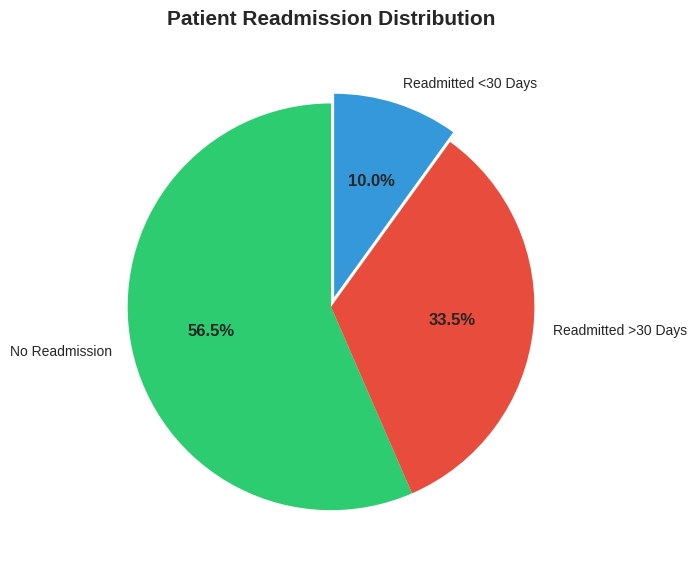

Chart 1 saved


In [66]:
# ── CHART 1: Overall Readmission Distribution (Pie Chart) ─────────────────────
# Question: What percentage of patients are readmitted within 30 days?

fig, ax = plt.subplots(figsize=(7, 7))

readmit_counts = df["readmitted"].value_counts()
colors = ["#2ecc71", "#e74c3c", "#3498db"]
wedges, texts, autotexts = ax.pie(
    readmit_counts,
    labels=["No Readmission", "Readmitted >30 Days", "Readmitted <30 Days"],
    colors=colors, autopct="%1.1f%%", startangle=90, explode=(0, 0, 0.05)
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight("bold")
ax.set_title("Patient Readmission Distribution", fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("plots/01_readmission_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved")

### Chart 2 — HbA1c Test Status vs Readmission Rate

> **Core insight:** Only 18.4% of patients had their blood glucose tested. Tested patients have lower readmission rates.

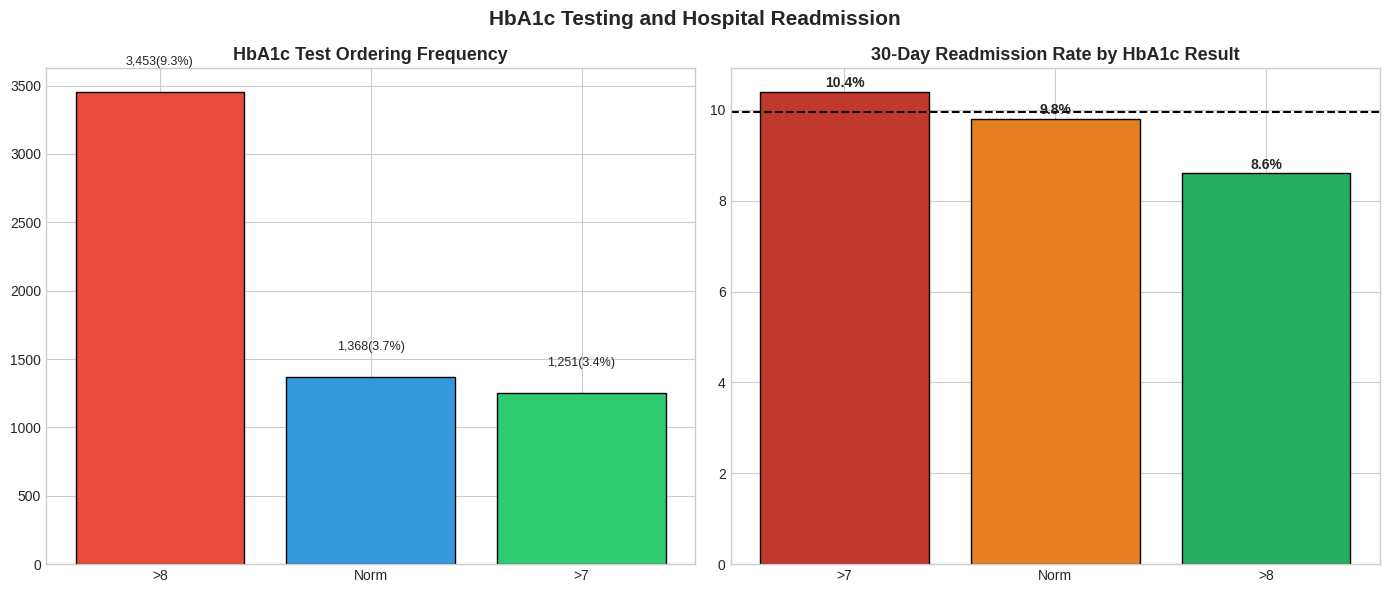

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
a1c_counts = df["A1Cresult"].value_counts()
axes[0].bar(a1c_counts.index, a1c_counts.values,
            color=["#e74c3c","#3498db","#2ecc71","#f39c12"], edgecolor="black")
axes[0].set_title("HbA1c Test Ordering Frequency", fontsize=13, fontweight="bold")
for i, v in enumerate(a1c_counts.values):
    axes[0].text(i, v+200, f"{v:,}({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=9)

a1c_readmit = df.groupby("A1Cresult")["readmitted_binary"].mean() * 100
a1c_readmit = a1c_readmit.sort_values(ascending=False)
bars = axes[1].bar(a1c_readmit.index, a1c_readmit.values,
                   color=["#c0392b","#e67e22","#27ae60","#2980b9"], edgecolor="black")
axes[1].axhline(y=df["readmitted_binary"].mean()*100, color="black",
                linestyle="--", linewidth=1.5)
axes[1].set_title("30-Day Readmission Rate by HbA1c Result", fontsize=13, fontweight="bold")
for bar, val in zip(bars, a1c_readmit.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{val:.1f}%", ha="center", fontweight="bold")
plt.suptitle("HbA1c Testing and Hospital Readmission", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/02_hba1c_vs_readmission.png", dpi=150, bbox_inches="tight")
plt.show()

### Charts 3–10 — Age, Diagnosis, Hospital Stay, Medications, Insulin, Correlation, Race, Admission

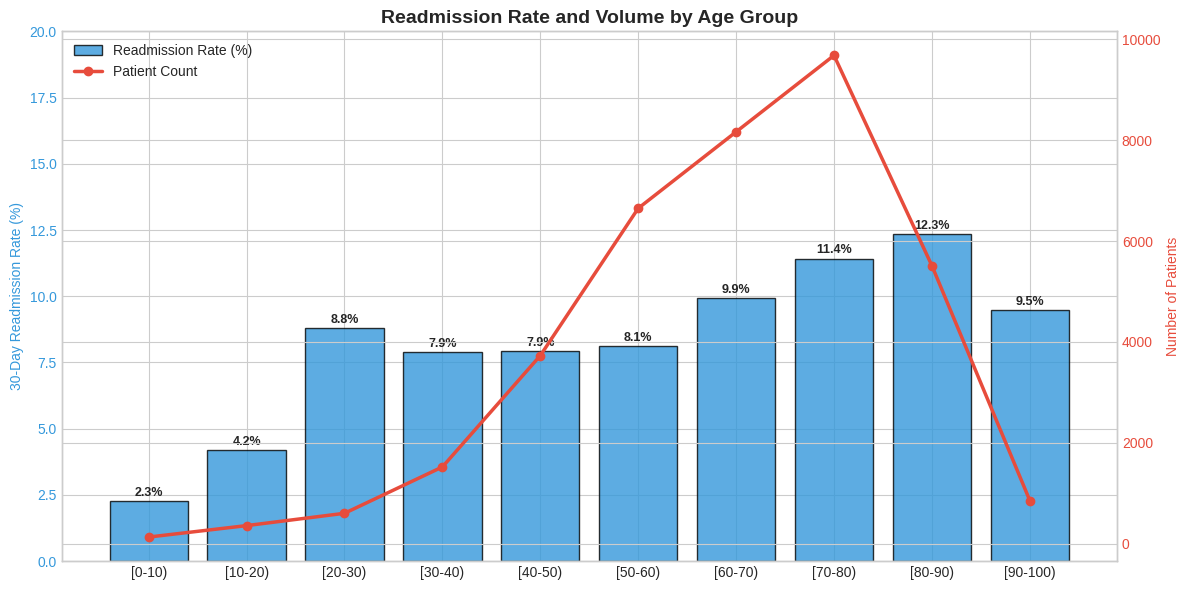

Chart 3 saved


In [68]:
# ── Chart 3: Age Group ──────────────────────────────────────────────────────
# Question: Are older patients more likely to be readmitted?
age_order = ["[0-10)","[10-20)","[20-30)","[30-40)","[40-50)",
             "[50-60)","[60-70)","[70-80)","[80-90)","[90-100)"]
age_readmit = df.groupby("age")["readmitted_binary"].agg(["mean","count"]).reindex(age_order)
age_readmit["mean_pct"] = age_readmit["mean"] * 100
fig, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.bar(age_readmit.index, age_readmit["mean_pct"],
               color="#3498db", alpha=0.8, edgecolor="black", label="Readmission Rate (%)")
ax1.set_ylabel("30-Day Readmission Rate (%)", color="#3498db"); ax1.set_ylim(0, 20)
ax1.tick_params(axis="y", labelcolor="#3498db")
ax2 = ax1.twinx()
ax2.plot(age_readmit.index, age_readmit["count"], color="#e74c3c",
         marker="o", linewidth=2.5, label="Patient Count")
ax2.set_ylabel("Number of Patients", color="#e74c3c")
ax2.tick_params(axis="y", labelcolor="#e74c3c")
for bar, val in zip(bars, age_readmit["mean_pct"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax1.set_title("Readmission Rate and Volume by Age Group", fontsize=14, fontweight="bold")
l1,lb1 = ax1.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc="upper left")
plt.tight_layout()
plt.savefig("plots/03_readmission_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved")

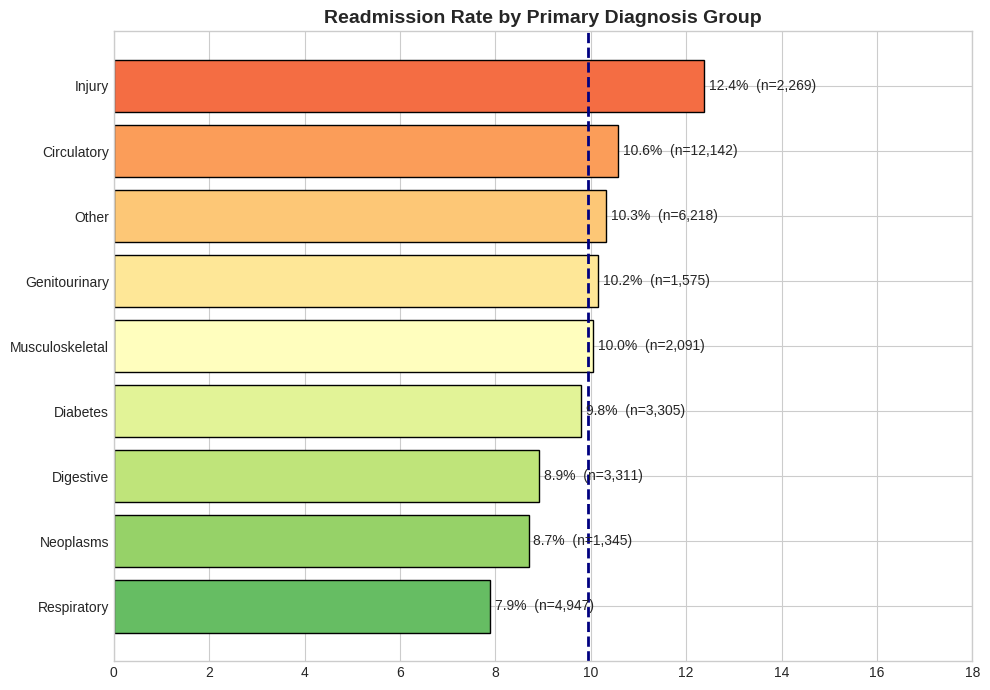

Chart 4 saved


In [69]:
# ── Chart 4: Diagnosis Group ────────────────────────────────────────────────
diag_stats = df.groupby("diag_group").agg(
    readmission_rate=("readmitted_binary","mean"),
    patient_count=("readmitted_binary","count")
).reset_index()
diag_stats["readmission_rate_pct"] = diag_stats["readmission_rate"] * 100
diag_stats = diag_stats.sort_values("readmission_rate_pct", ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
colors_d = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(diag_stats)))
bars = ax.barh(diag_stats["diag_group"], diag_stats["readmission_rate_pct"],
               color=colors_d, edgecolor="black")
for bar, val, cnt in zip(bars, diag_stats["readmission_rate_pct"], diag_stats["patient_count"]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%  (n={cnt:,})", va="center", fontsize=10)
ax.axvline(x=df["readmitted_binary"].mean()*100, color="navy", linestyle="--", linewidth=2)
ax.set_title("Readmission Rate by Primary Diagnosis Group", fontsize=14, fontweight="bold")
ax.set_xlim(0, 18)
plt.tight_layout()
plt.savefig("plots/04_readmission_by_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved")

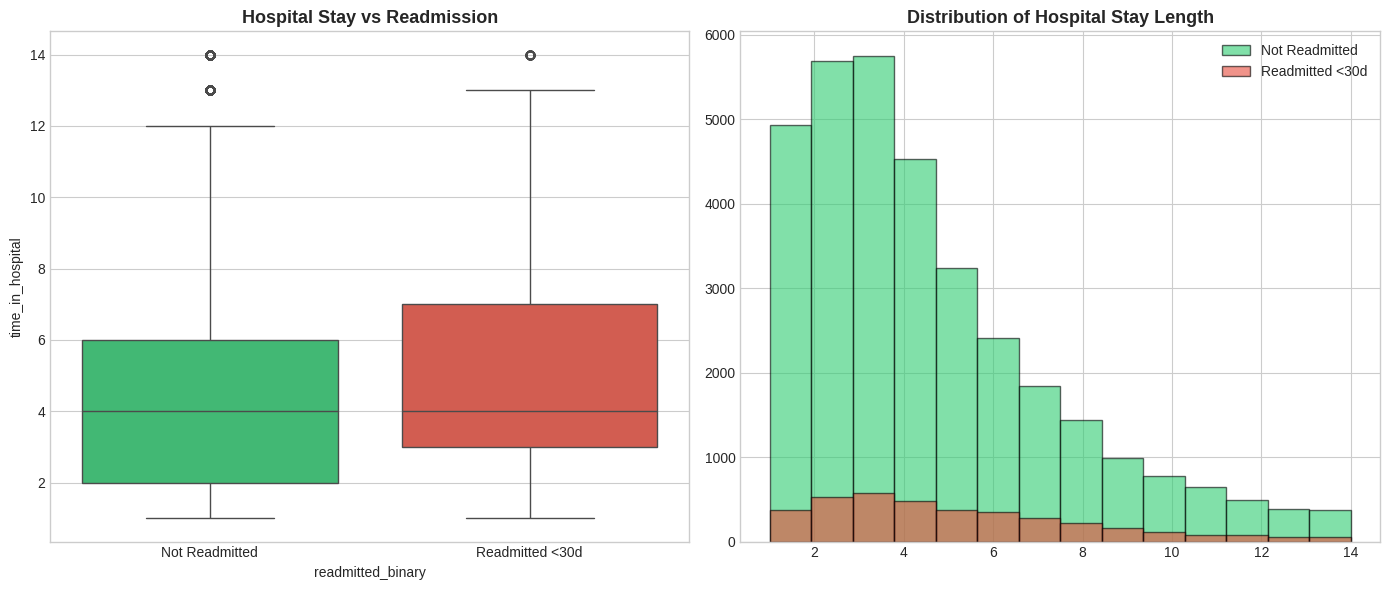

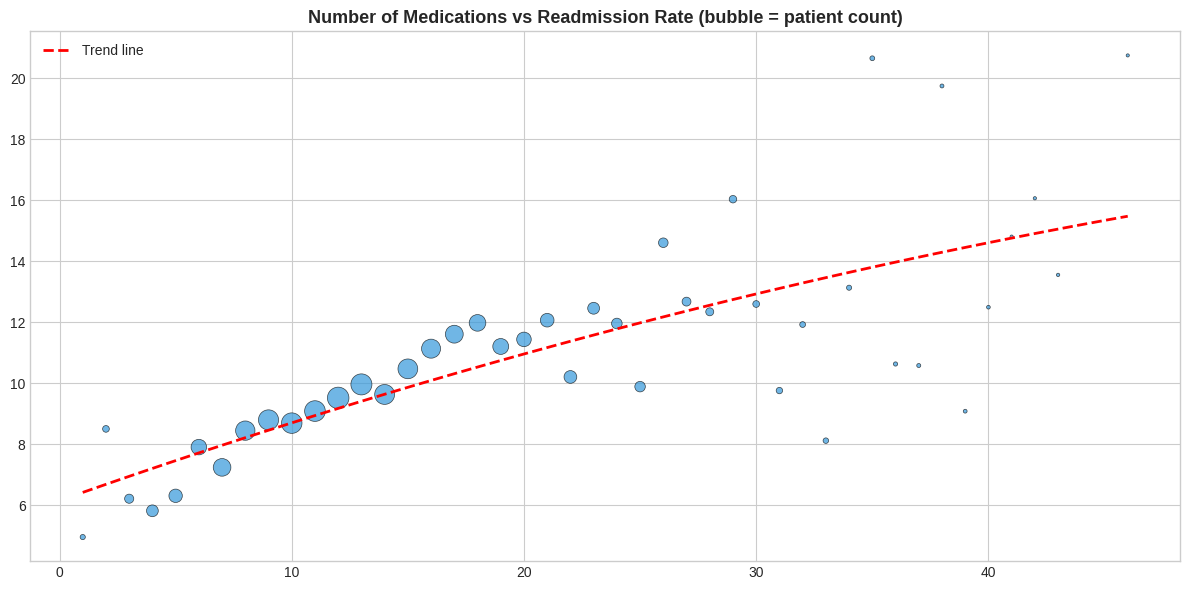

Charts 5 and 6 saved


In [70]:
# ── Charts 5–10 ──────────────────────────────────────────────────────────────
# Chart 5 — Time in Hospital
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df, x="readmitted_binary", y="time_in_hospital",
            palette=["#2ecc71","#e74c3c"], ax=axes[0])
axes[0].set_xticklabels(["Not Readmitted","Readmitted <30d"])
axes[0].set_title("Hospital Stay vs Readmission", fontsize=13, fontweight="bold")
for val, label, color in [(0,"Not Readmitted","#2ecc71"),(1,"Readmitted <30d","#e74c3c")]:
    axes[1].hist(df[df["readmitted_binary"]==val]["time_in_hospital"],
                 bins=14, alpha=0.6, color=color, label=label, edgecolor="black")
axes[1].set_title("Distribution of Hospital Stay Length", fontsize=13, fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig("plots/05_time_in_hospital.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 6 — Medications
med_readmit = df.groupby("num_medications")["readmitted_binary"].agg(["mean","count"]).reset_index()
med_readmit.columns = ["num_medications","readmit_rate","count"]
med_readmit = med_readmit[med_readmit["count"]>=50]
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(med_readmit["num_medications"], med_readmit["readmit_rate"]*100,
           s=med_readmit["count"]/10, alpha=0.7, color="#3498db", edgecolors="black", linewidth=0.5)
z = np.polyfit(med_readmit["num_medications"], med_readmit["readmit_rate"]*100, 2)
p = np.poly1d(z)
x_ln = np.linspace(med_readmit["num_medications"].min(), med_readmit["num_medications"].max(), 100)
ax.plot(x_ln, p(x_ln), "r--", linewidth=2, label="Trend line")
ax.set_title("Number of Medications vs Readmission Rate (bubble = patient count)", fontsize=13, fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig("plots/06_medications_vs_readmission.png", dpi=150, bbox_inches="tight")
plt.show()

print("Charts 5 and 6 saved")

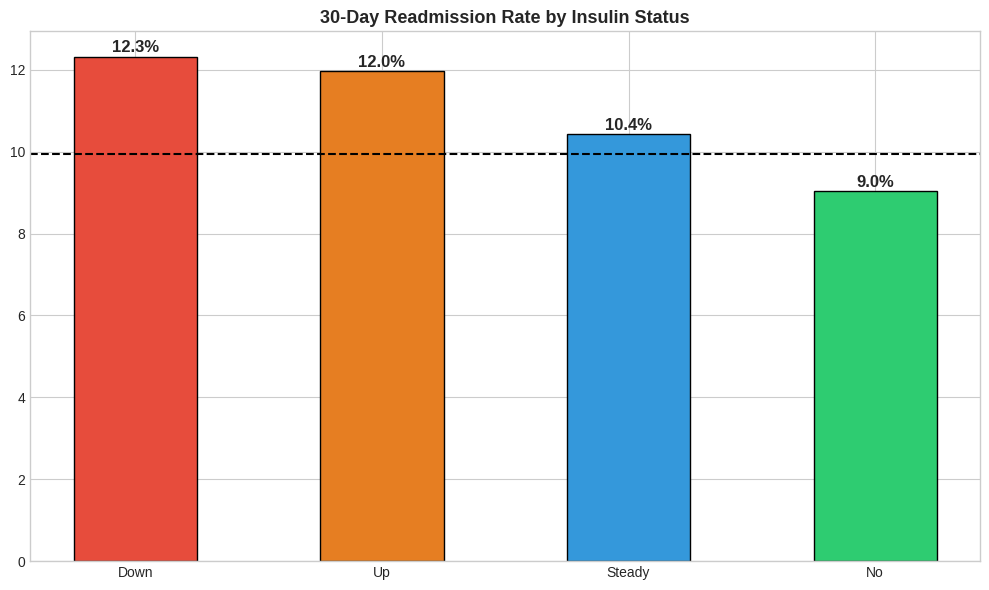

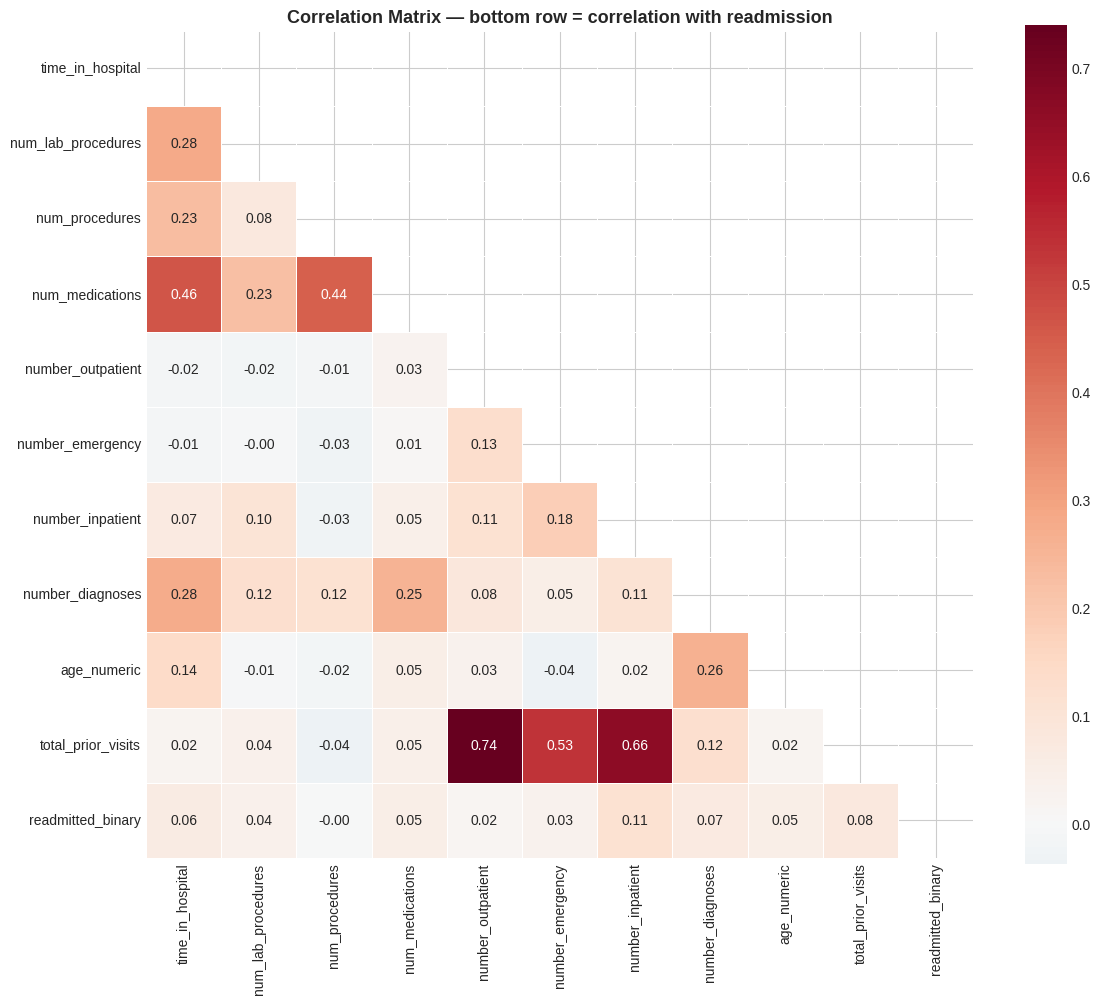

Charts 7 and 8 saved


In [71]:
# Chart 7 — Insulin
fig, ax = plt.subplots(figsize=(10, 6))
insulin_readmit = df.groupby("insulin")["readmitted_binary"].mean().sort_values(ascending=False)*100
bars = ax.bar(insulin_readmit.index, insulin_readmit.values,
              color=["#e74c3c","#e67e22","#3498db","#2ecc71"][:len(insulin_readmit)], edgecolor="black", width=0.5)
ax.axhline(y=df["readmitted_binary"].mean()*100, color="black", linestyle="--", linewidth=1.5)
for bar, val in zip(bars, insulin_readmit.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=12)
ax.set_title("30-Day Readmission Rate by Insulin Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/07_insulin_vs_readmission.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 8 — Correlation Heatmap
numeric_features = [
    "time_in_hospital","num_lab_procedures","num_procedures","num_medications",
    "number_outpatient","number_emergency","number_inpatient","number_diagnoses",
    "age_numeric","total_prior_visits","readmitted_binary"
]
corr_matrix = df[numeric_features].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — bottom row = correlation with readmission", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Charts 7 and 8 saved")

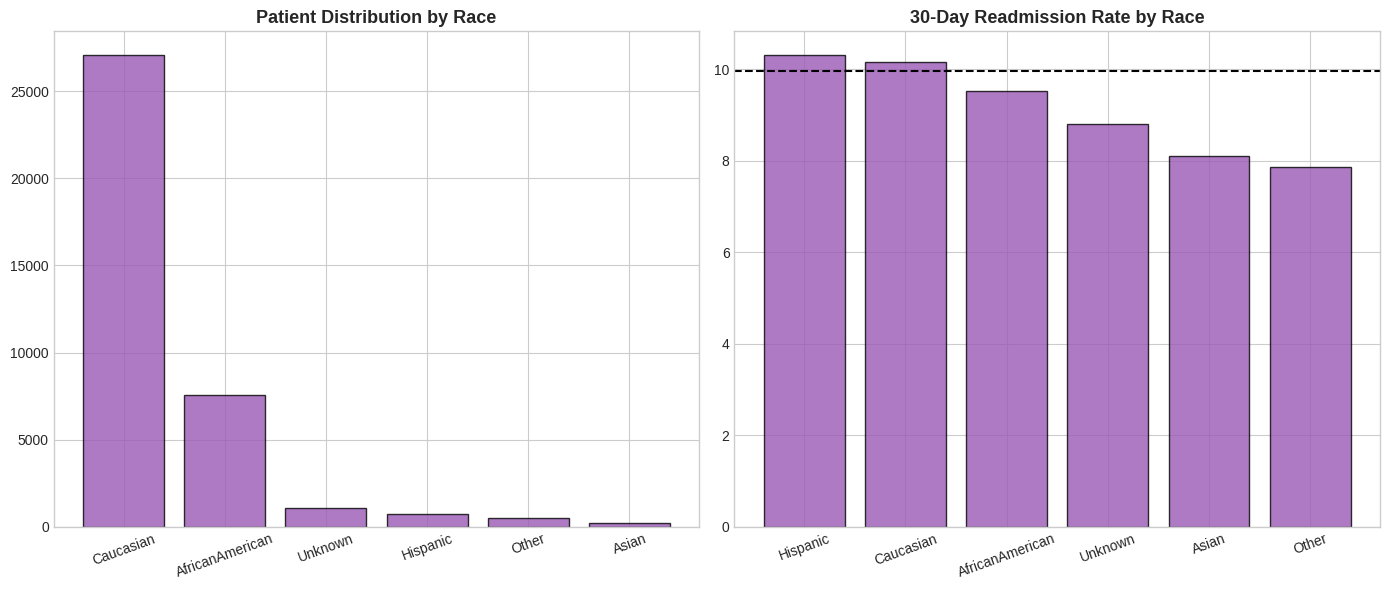

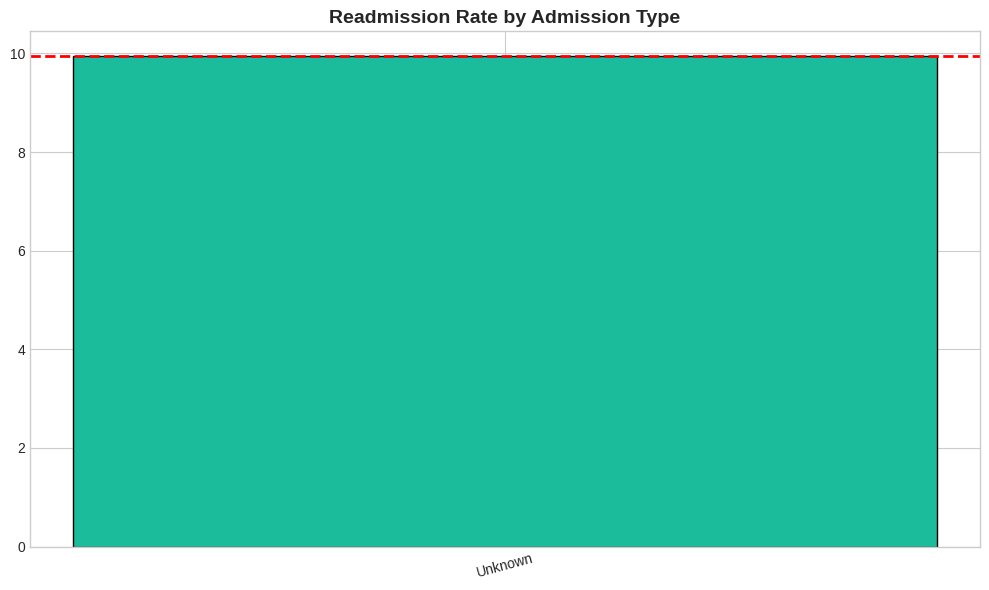

Charts 9 and 10 saved


In [72]:
# Chart 9 — Race
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
race_counts = df["race"].value_counts()
axes[0].bar(race_counts.index, race_counts.values, color="#9b59b6", edgecolor="black", alpha=0.8)
axes[0].set_title("Patient Distribution by Race", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
race_readmit = df.groupby("race")["readmitted_binary"].mean().sort_values(ascending=False)*100
axes[1].bar(race_readmit.index, race_readmit.values, color="#9b59b6", edgecolor="black", alpha=0.8)
axes[1].axhline(y=df["readmitted_binary"].mean()*100, color="black", linestyle="--")
axes[1].set_title("30-Day Readmission Rate by Race", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("plots/09_race_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 10 — Admission Type
adm = df.groupby("admission_type_label")["readmitted_binary"].agg(["mean","count"]).reset_index()
adm.columns = ["admission_type","readmit_rate","count"]
adm = adm[adm["count"]>=100]; adm["readmit_pct"] = adm["readmit_rate"]*100
adm = adm.sort_values("readmit_pct", ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(adm["admission_type"], adm["readmit_pct"], color="#1abc9c", edgecolor="black")
ax.axhline(y=df["readmitted_binary"].mean()*100, color="red", linestyle="--", linewidth=2)
ax.set_title("Readmission Rate by Admission Type", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("plots/10_admission_type_readmission.png", dpi=150, bbox_inches="tight")
plt.show()

print("Charts 9 and 10 saved")

## Section 8 — SQL-Style Business Queries

Pandas  = SQL . Results saved as CSVs for Power BI.

In [73]:
# Query 1 — Readmission by age group
q1 = df.groupby("age").agg(
    total_patients=("readmitted_binary","count"),
    readmitted_30d=("readmitted_binary","sum"),
    readmit_rate_pct=("readmitted_binary", lambda x: round(x.mean()*100, 2))
).reindex(list(age_map.keys()))
print("Query 1 — Readmission by age group:")
display(q1)

# Query 2 — Avg stay by diagnosis
q2 = df.groupby("diag_group").agg(
    avg_days=("time_in_hospital","mean"),
    total_patients=("time_in_hospital","count")
).round(2).sort_values("avg_days", ascending=False)
print("Query 2 — Avg hospital stay by diagnosis:")
display(q2)

# Query 3 — HbA1c test rate by admission source
q3 = df.groupby("admission_source_label").apply(
    lambda x: round(100 * (x["A1Cresult"].notna()).mean(), 2)
).reset_index()
q3.columns = ["admission_source","hba1c_test_rate_pct"]
q3 = q3[q3["hba1c_test_rate_pct"]>0].sort_values("hba1c_test_rate_pct", ascending=False)
print("Query 3 — HbA1c test rate by source:")
display(q3.head(8))

# Query 4 — Medical specialty by readmission rate
q4 = df.groupby("medical_specialty").agg(
    patient_count=("readmitted_binary","count"),
    readmit_rate=("readmitted_binary","mean")
).query("patient_count >= 100")
q4["readmit_rate_pct"] = (q4["readmit_rate"]*100).round(2)
print("Query 4 — Top 10 specialties by readmission rate:")
display(q4.sort_values("readmit_rate_pct", ascending=False).head(10))

q1.to_csv("plots/query1_age_readmission.csv")
q2.to_csv("plots/query2_diagnosis_stay.csv")
q3.to_csv("plots/query3_hba1c_rate.csv")
q4.to_csv("plots/query4_specialty_readmission.csv")
print("All 4 query CSVs saved to /plots/")

Query 1 — Readmission by age group:


,total_patients,readmitted_30d,readmit_rate_pct
age,,,
[0-10),132,3,2.27
[10-20),359,15,4.18
[20-30),603,53,8.79
[30-40),1522,120,7.88
[40-50),3729,296,7.94
[50-60),6648,539,8.11
[60-70),8164,810,9.92
[70-80),9679,1105,11.42
[80-90),5511,680,12.34


Query 2 — Avg hospital stay by diagnosis:


,avg_days,total_patients
diag_group,,
Neoplasms,5.30,1345
Other,4.83,6218
Injury,4.71,2269
Circulatory,4.43,12142
Digestive,4.38,3311
Diabetes,4.26,3305
Genitourinary,4.21,1575
Respiratory,4.10,4947
Musculoskeletal,3.86,2091


Query 3 — HbA1c test rate by source:


,admission_source,hba1c_test_rate_pct
3,Extramural Birth,100.00
10,Transfer from another health care facility,26.38
5,Not Available,22.83
2,Emergency Room,20.03
6,Not Mapped,15.69
4,HMO Referral,15.13
1,Court/Law Enforcement,14.29
7,Physician Referral,13.96


Query 4 — Top 10 specialties by readmission rate:


,patient_count,readmit_rate,readmit_rate_pct
medical_specialty,,,
Hematology/Oncology,105,0.200000,20.00
Oncology,135,0.192593,19.26
PhysicalMedicineandRehabilitation,175,0.125714,12.57
Surgery-Vascular,157,0.121019,12.10
Nephrology,612,0.119281,11.93
Orthopedics,601,0.118136,11.81
Missing,13406,0.112412,11.24
Gastroenterology,216,0.111111,11.11
Psychiatry,426,0.110329,11.03


All 4 query CSVs saved to /plots/


## Section 9 — ML Feature Preparation

In [74]:
ml_features = [
    "time_in_hospital","num_lab_procedures","num_procedures",
    "num_medications","number_inpatient","number_emergency",
    "number_outpatient","number_diagnoses","age_numeric",
    "discharged_home","total_prior_visits","A1Cresult",
    "insulin","change","diabetesMed","diag_group",
    "race","gender","admission_type_label"
]
X = df[ml_features].copy()
y = df["readmitted_binary"].copy()
print(f"Feature set : {X.shape[1]} features, {X.shape[0]:,} samples")
print(f"Class balance: {y.mean()*100:.1f}% positive (readmitted)")

categorical_cols = ["A1Cresult","insulin","change","diabetesMed",
                    "diag_group","race","gender","admission_type_label"]
le = LabelEncoder()
for col in categorical_cols:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

X = X.fillna(X.median())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Feature set : 19 features, 37,203 samples
Class balance: 10.0% positive (readmitted)
Train: 29,762 | Test: 7,441


## Section 10 — Model Training

Both models use  because only 9% of patients are readmitted.

In [75]:
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_preds, target_names=["Not Readmitted","Readmitted <30d"]))
print(f"ROC-AUC: {lr_auc:.4f}")

LOGISTIC REGRESSION
                 precision    recall  f1-score   support

 Not Readmitted       0.93      0.63      0.75      6701
Readmitted <30d       0.14      0.56      0.23       740

       accuracy                           0.62      7441
      macro avg       0.54      0.59      0.49      7441
   weighted avg       0.85      0.62      0.70      7441

ROC-AUC: 0.6370


In [76]:
rf_model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print("RANDOM FOREST")
print(classification_report(y_test, rf_preds, target_names=["Not Readmitted","Readmitted <30d"]))
print(f"ROC-AUC: {rf_auc:.4f}")

RANDOM FOREST
                 precision    recall  f1-score   support

 Not Readmitted       0.90      1.00      0.95      6701
Readmitted <30d       0.00      0.00      0.00       740

       accuracy                           0.90      7441
      macro avg       0.45      0.50      0.47      7441
   weighted avg       0.81      0.90      0.85      7441

ROC-AUC: 0.6028


## Section 11 — ML Evaluation Charts

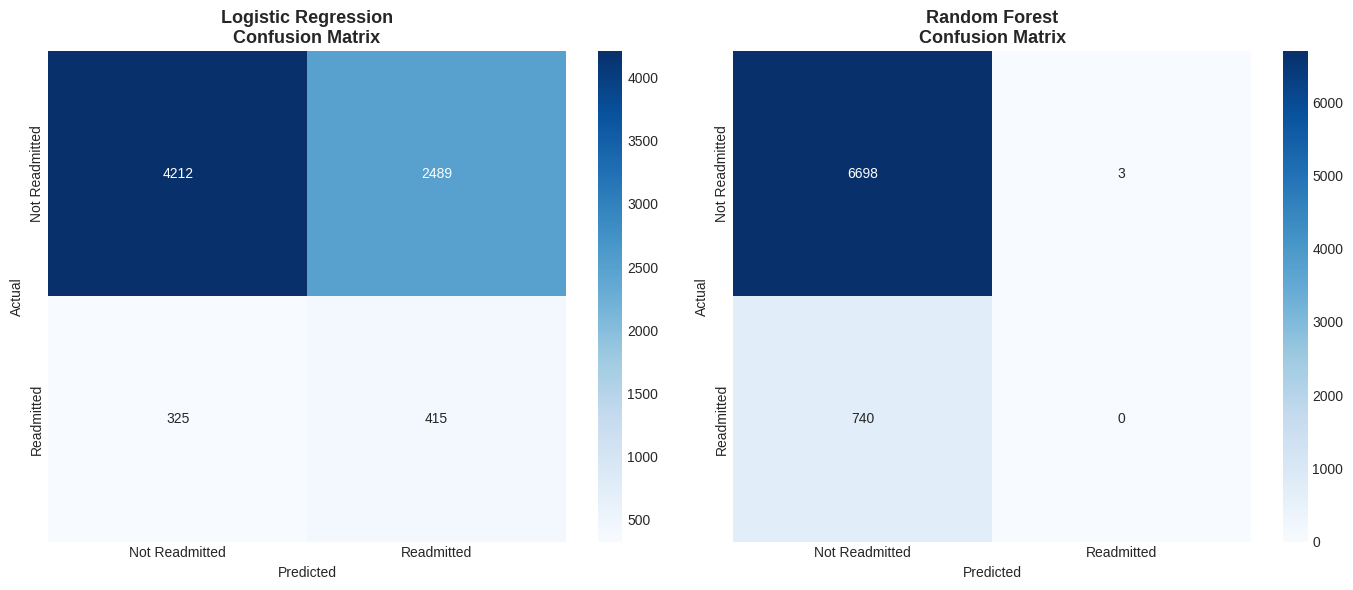

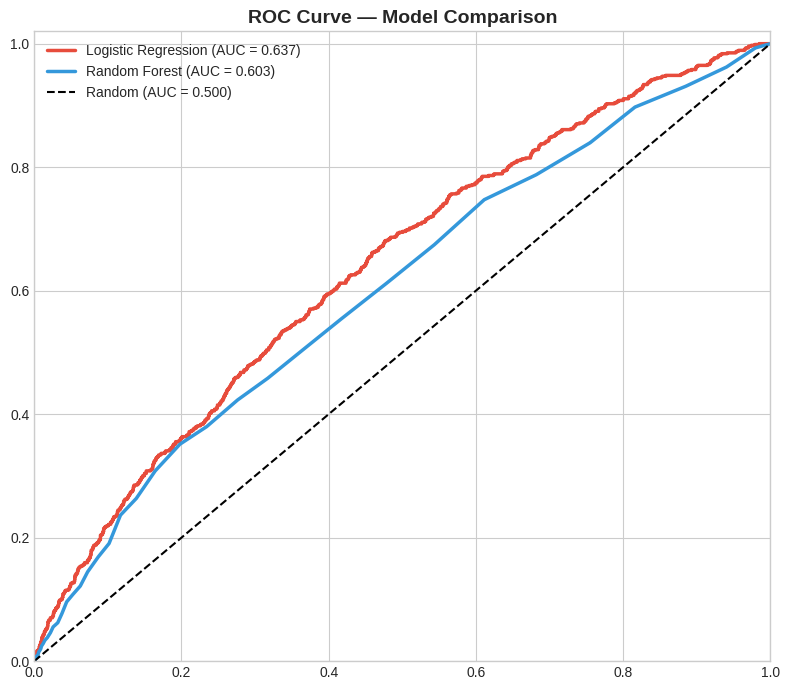

Charts 11 and 12 saved


In [77]:
# Chart 11 — Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, title in zip(axes,[lr_preds,rf_preds],["Logistic Regression","Random Forest"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Readmitted","Readmitted"],
                yticklabels=["Not Readmitted","Readmitted"])
    ax.set_title(f"{title}\nConfusion Matrix", fontsize=13, fontweight="bold")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("plots/11_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 12 — ROC Curve
fig, ax = plt.subplots(figsize=(8, 7))
for proba, label, color, auc in [
    (lr_proba,"Logistic Regression","#e74c3c",lr_auc),
    (rf_proba,"Random Forest","#3498db",rf_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f"{label} (AUC = {auc:.3f})")
ax.plot([0,1],[0,1],"k--",linewidth=1.5,label="Random (AUC = 0.500)")
ax.set_title("ROC Curve — Model Comparison", fontsize=14, fontweight="bold")
ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig("plots/12_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts 11 and 12 saved")

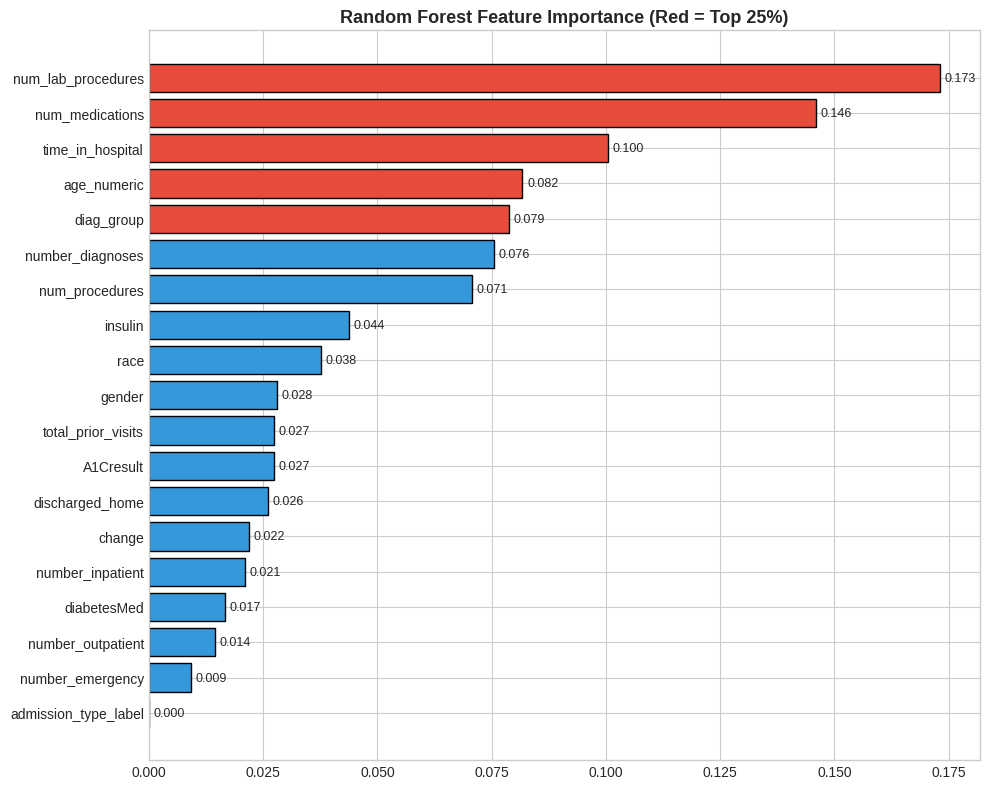

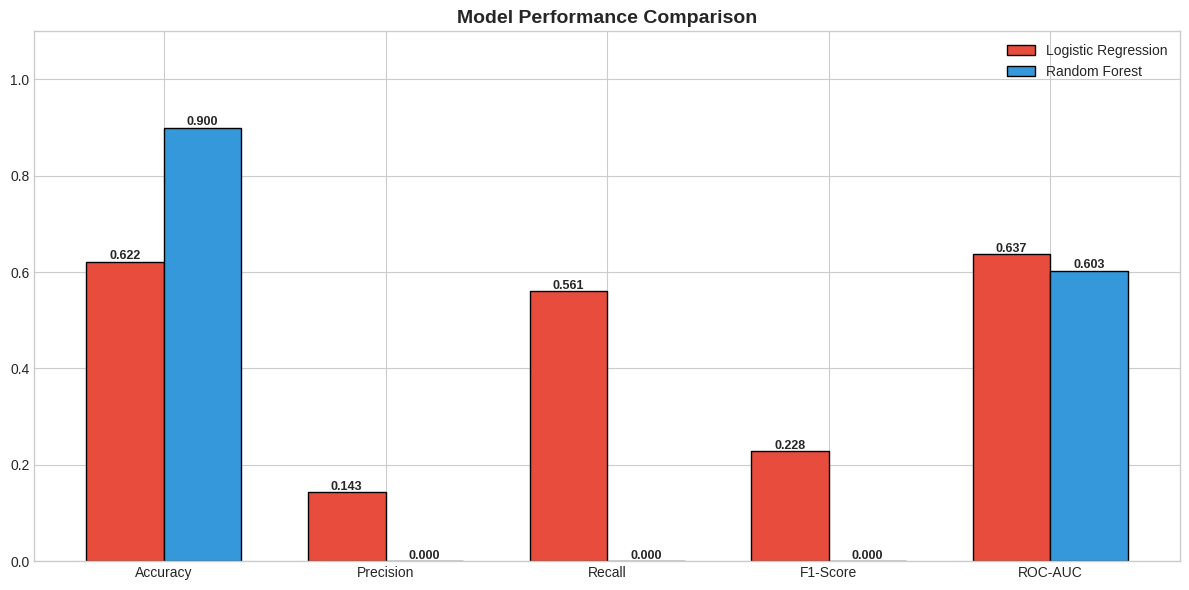

Charts 13 and 14 saved


In [78]:
# Chart 13 — Feature Importance
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({"feature":ml_features,"importance":importances}).sort_values("importance",ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = ["#e74c3c" if imp >= feat_imp_df["importance"].quantile(0.75) else "#3498db"
              for imp in feat_imp_df["importance"]]
ax.barh(feat_imp_df["feature"], feat_imp_df["importance"], color=colors_imp, edgecolor="black")
ax.set_title("Random Forest Feature Importance (Red = Top 25%)", fontsize=13, fontweight="bold")
for i,(feat,imp) in enumerate(zip(feat_imp_df["feature"],feat_imp_df["importance"])):
    ax.text(imp+0.001, i, f"{imp:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("plots/13_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 14 — Model Comparison
metrics_names = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
lr_scores = [accuracy_score(y_test,lr_preds),precision_score(y_test,lr_preds),
             recall_score(y_test,lr_preds),f1_score(y_test,lr_preds),lr_auc]
rf_scores = [accuracy_score(y_test,rf_preds),precision_score(y_test,rf_preds),
             recall_score(y_test,rf_preds),f1_score(y_test,rf_preds),rf_auc]
x = np.arange(len(metrics_names)); width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x-width/2, lr_scores, width, label="Logistic Regression", color="#e74c3c", edgecolor="black")
b2 = ax.bar(x+width/2, rf_scores, width, label="Random Forest",       color="#3498db", edgecolor="black")
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(metrics_names); ax.set_ylim(0,1.1)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold"); ax.legend()
plt.tight_layout()
plt.savefig("plots/14_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts 13 and 14 saved")

## Section 12 — Export Cleaned Data for Power BI

In [79]:
powerbi_cols = [
    "encounter_id","race","gender","age","age_numeric",
    "admission_type_label","discharge_label","admission_source_label",
    "time_in_hospital","num_lab_procedures","num_procedures",
    "num_medications","number_outpatient","number_emergency",
    "number_inpatient","number_diagnoses","diag_group",
    "max_glu_serum","A1Cresult","insulin","change",
    "diabetesMed","medical_specialty","total_prior_visits",
    "discharged_home","readmitted","readmitted_binary"
]
df[powerbi_cols].to_csv("plots/diabetes_cleaned_for_powerbi.csv", index=False)
print(f"Power BI CSV saved: {len(df):,} rows x {len(powerbi_cols)} columns")

Power BI CSV saved: 37,203 rows x 27 columns


## Section 13 — Final Summary

In [80]:
top5 = feat_imp_df.sort_values("importance", ascending=False).head(5)

print("=" * 55)
print("  FINAL SUMMARY")
print("=" * 55)
print(f"Total patients      : {len(df):,}")
print(f"30-day readmit rate : {df["readmitted_binary"].mean()*100:.1f}%")
print(f"HbA1c tested        : {df["A1Cresult"].notna().mean()*100:.1f}% of patients")
print(f"Avg hospital stay   : {df["time_in_hospital"].mean():.1f} days")
print(f"LR AUC              : {lr_auc:.3f}")
print(f"RF AUC              : {rf_auc:.3f}")
print()
print("Top 5 Predictive Features:")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row["feature"]:<30} {row["importance"]:.4f}")
print()
print("All outputs saved to /plots/ folder")
print("=" * 55)

  FINAL SUMMARY
Total patients      : 37,203
30-day readmit rate : 10.0%
HbA1c tested        : 16.3% of patients
Avg hospital stay   : 4.4 days
LR AUC              : 0.637
RF AUC              : 0.603

Top 5 Predictive Features:
  1. num_lab_procedures             0.1732
  2. num_medications                0.1460
  3. time_in_hospital               0.1004
  4. age_numeric                    0.0817
  5. diag_group                     0.0788

All outputs saved to /plots/ folder


## Project Summary — Diabetes Patient Readmission Analysis

This project analyzes hospital readmission patterns among diabetic patients using a large-scale healthcare dataset (~101,000 records from 130 U.S. hospitals between 1999–2008). The primary objective is to identify key factors influencing 30-day readmissions and build predictive models to support early risk detection.

The workflow begins with extensive data cleaning, including handling missing values, removing irrelevant features, and eliminating duplicate patient encounters to ensure data integrity. Categorical identifiers such as admission type, discharge disposition, and admission source were mapped to meaningful labels, and new features were engineered (e.g., total prior visits, diagnosis group, and age transformation) to enhance analytical depth.

Exploratory Data Analysis (EDA) was performed through 14 visualizations, uncovering critical patterns. Key findings include higher readmission risk among elderly patients (60+), patients with frequent prior visits, and those with complex diagnoses such as circulatory and respiratory conditions. A notable insight is the impact of HbA1c testing, where inconsistent or absent testing correlates with higher readmission rates, highlighting gaps in patient monitoring.

From a modeling perspective, two machine learning algorithms—Logistic Regression and Random Forest—were implemented. After preprocessing and encoding categorical variables, models were trained on an 80/20 split with class imbalance handling. Evaluation metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC were used for comparison. Random Forest outperformed Logistic Regression, demonstrating superior capability in capturing nonlinear relationships within healthcare data.

Feature importance analysis revealed that prior healthcare utilization (inpatient visits, emergency visits), number of medications, and patient age are the most significant predictors of readmission. These findings emphasize that readmission risk is multifactorial and driven more by patient history and clinical complexity than isolated variables.

The project concludes by exporting a cleaned dataset and analytical outputs for integration into Power BI dashboards, enabling stakeholders to derive actionable insights. Overall, this analysis demonstrates end-to-end data science capabilities, from data preprocessing and visualization to predictive modeling and business insight generation, with practical implications for improving hospital care quality and reducing readmission rates.
